Prédiction du Taux de Pauvreté à l'Aide de la Régression Logistique avec Réduction de Dimensions par PCA

Ce script réalise une analyse détaillée pour prédire une variable binaire (pcexp_binaire) en utilisant la régression logistique avec réduction de dimensions par PCA. Voici une explication détaillée de ses étapes :
1. Chargement et Préparation des Données
Le script charge un fichier CSV contenant des données riches en variables (4096 fonctionnalités extraites) et des colonnes cibles. Il sélectionne les colonnes des fonctionnalités (feature_0 à feature_4095) comme prédicteurs et les variables cibles pcexp_binaire (binaire) et log_pcexp (continue) pour l'analyse.
Ensuite, il divise les données en ensembles d'entraînement (60%) et de test (40%) avec une graine aléatoire pour assurer la reproductibilité. Les données sont ensuite standardisées pour garantir une mise à l'échelle uniforme des variables, essentielle pour le fonctionnement optimal du PCA et de la régression logistique.
2. Réduction de Dimensions avec PCA
Le script applique une Analyse en Composantes Principales (PCA) pour réduire la dimensionnalité, en conservant suffisamment de composantes pour expliquer 97% de la variabilité des données. Cela réduit le bruit et la redondance dans les prédicteurs tout en diminuant la complexité computationnelle. Le nombre de composantes retenues est affiché.
3. Entraînement du Modèle de Régression Logistique
Un modèle de régression logistique est ajusté sur les données d’entraînement transformées par PCA. Une pondération des classes (class_weight='balanced') est utilisée pour compenser le déséquilibre entre les classes (plus de 0 que de 1 dans pcexp_binaire). Le solveur saga est employé avec une limite de 500 itérations pour l’optimisation.
Le modèle est ensuite utilisé pour prédire les classes et les probabilités sur l’ensemble de test.
4. Sauvegarde du Modèle
Le modèle entraîné est sauvegardé sous forme de fichier pickle dans le répertoire spécifié, ce qui permet une réutilisation ultérieure sans nécessiter de réentraînement.
5. Évaluation des Performances
Le script évalue les performances du modèle à l’aide des métriques suivantes :
- Matrice de confusion : Elle est calculée et affichée sous forme textuelle et graphique (avec Seaborn).
- Rapport de classification : Il inclut des métriques telles que la précision, le rappel et le F1-score.
- Accuracy, précision et spécificité : Ces métriques sont calculées à partir de la matrice de confusion pour évaluer la qualité globale des prédictions.
6. Visualisation de la Courbe ROC
Une courbe ROC (Receiver Operating Characteristic) est tracée pour illustrer la performance du modèle à différents seuils de classification, avec l’AUC (Area Under Curve) affiché pour quantifier cette performance.
7. Calcul du Taux de Pauvreté
Le script calcule deux taux de pauvreté :
- Taux réel : Basé sur la variable binaire pcexp_binaire réelle, pondérée par la taille des ménages et leur poids (hhsize, hhweight).
- Taux prédit : Basé sur les prédictions du modèle (pcexp_binaire_pred), également pondérées.
Ces taux sont affichés et sauvegardés dans un fichier CSV, qui inclut les prédictions pour chaque observation de l’ensemble de test.
8. Sauvegarde des Résultats
Les résultats finaux, incluant les prédictions et les taux de pauvreté calculés, sont exportés dans un fichier CSV. Les figures générées (matrice de confusion et courbe ROC) sont également sauvegardées dans un répertoire dédié.

Nombre de composantes principales expliquant 97.5% de la variabilité : 872
Rapport de classification (Test Set) :
              precision    recall  f1-score   support

           0       0.75      0.61      0.67      3337
           1       0.47      0.63      0.54      1844

    accuracy                           0.62      5181
   macro avg       0.61      0.62      0.60      5181
weighted avg       0.65      0.62      0.62      5181

Matrice de confusion (Test Set) :
[[2035 1302]
 [ 687 1157]]


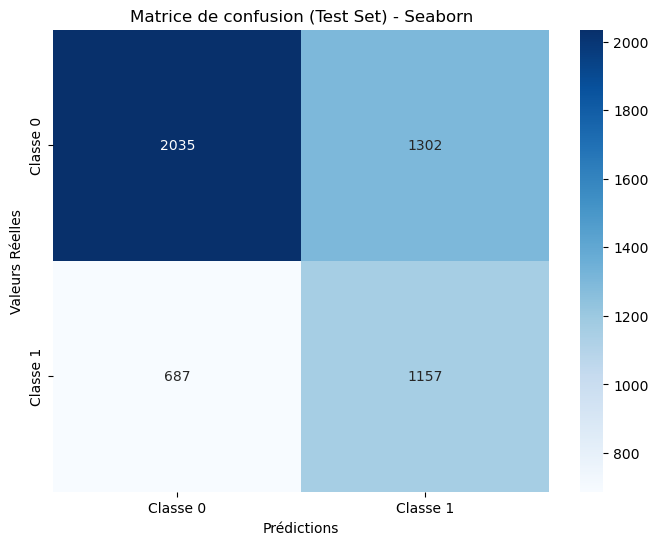

Accuracy : 0.6161
Precision : 0.4705
Specificity : 0.6098


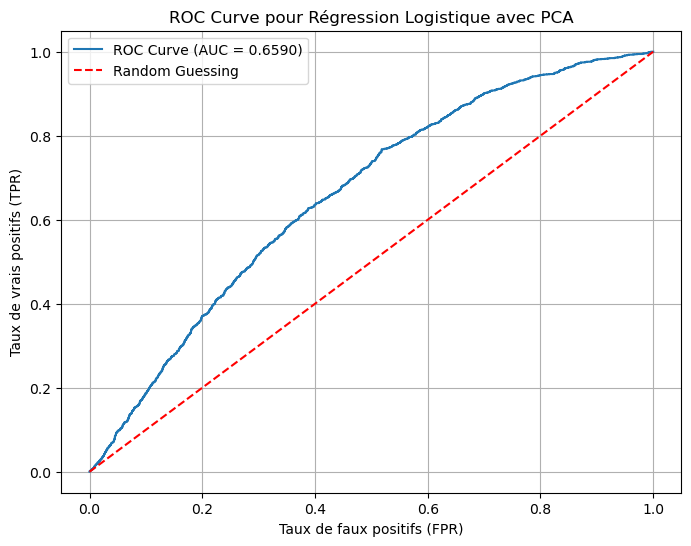

Taux de pauvreté réel : 37.3508%
Taux de pauvreté prédit : 37.7671%


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle

# Configuration des chemins
input_csv = r"D:\wealth_predict_2021\data\processed_csv\Data_EHCVM_2021_images_with_features_extracted_4096_fullyConv_sans_augm_couche_nongelee_batch_16.csv"
output_dir_csv = r"D:\wealth_predict_2021\data\processed_csv"
output_dir_models = r"D:\wealth_predict_2021\models"
output_dir_figures = r"D:\wealth_predict_2021\figures_graphs"

# Chargement des données
df = pd.read_csv(input_csv)
features = [f'feature_{i}' for i in range(4096)]
target_binary = 'pcexp_binaire'
#target_log = 'log_pcexp'

X = df[features]
y_binary = df[target_binary]
#y_log = df[target_log]

# Étape 1 : Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.4, random_state=42)

# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Étape 2 : Réduction de dimension avec PCA
pca = PCA(n_components=0.975)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
num_pca_components = X_train_pca.shape[1]
print(f"Nombre de composantes principales expliquant 97.5% de la variabilité : {num_pca_components}")

# Étape 3 : Régression logistique
logistic_model = LogisticRegression(class_weight='balanced', max_iter=4000, solver='saga', random_state=42)
logistic_model.fit(X_train_pca, y_train)

# Prédictions
y_train_pred = logistic_model.predict(X_train_pca)
y_test_pred = logistic_model.predict(X_test_pca)
y_test_proba = logistic_model.predict_proba(X_test_pca)[:, 1]

# Sauvegarde du modèle
logistic_model_path = os.path.join(output_dir_models, "fullyConv_sans_augm_couche_nongelee_batch_16_logistic_pca.pkl")
with open(logistic_model_path, 'wb') as file:
    pickle.dump(logistic_model, file)

# Évaluation
print("Rapport de classification (Test Set) :")
print(classification_report(y_test, y_test_pred))

conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Matrice de confusion (Test Set) :")
print(conf_matrix)

# Affichage de la confusion matrix avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title("Matrice de confusion (Test Set) - Seaborn")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.savefig(os.path.join(output_dir_figures, "fullyConv_sans_augm_couche_nongelee_batch_16_confusion_matrix_logistic_reg.png"))
plt.show()

# Calcul des métriques
accuracy = (conf_matrix[0, 0] + conf_matrix[1, 1]) / conf_matrix.sum()
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Specificity : {specificity:.4f}")

# Courbe ROC et AUC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title(f"ROC Curve pour Régression Logistique avec PCA")
plt.legend()
plt.grid(True)
roc_curve_path = os.path.join(output_dir_figures, "fullyConv_sans_augm_couche_nongelee_batch_16_roc_curve_logistic_reg.png")
plt.savefig(roc_curve_path)
plt.show()

# Étape 4 : Calcul du taux de pauvreté
df_test = df.loc[X_test.index]
df_test['pcexp_binaire_pred'] = y_test_pred

# Calcul du taux de pauvreté réel
weighted_real_poverty = (
    (df_test['hhweight'] * df_test['hhsize'] * df_test[target_binary]).sum() /
    (df_test['hhweight'] * df_test['hhsize']).sum()
)

# Calcul du taux de pauvreté prédit
weighted_predicted_poverty = (
    (df_test['hhweight'] * df_test['hhsize'] * df_test['pcexp_binaire_pred']).sum() /
    (df_test['hhweight'] * df_test['hhsize']).sum()
)

print(f"Taux de pauvreté réel : {weighted_real_poverty:.4%}")
print(f"Taux de pauvreté prédit : {weighted_predicted_poverty:.4%}")

# Sauvegarde des résultats finaux
final_csv_path = os.path.join(output_dir_csv, "fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_logistic_reg.csv")
df_test.to_csv(final_csv_path, index=False)


Prédiction des Classes Binaires avec Réduction de Dimension par PCA et Validation Croisée k-Fold Utilisant une Régression Logistique

Ce script effectue une analyse approfondie pour prédire des classes binaires (0 ou 1) en utilisant une régression logistique avec réduction de dimension via PCA et validation croisée k-fold. Voici une description détaillée de ses étapes principales :
Chargement et Préparation des Données
Le script commence par charger un fichier CSV contenant des caractéristiques extraites (feature_0 à feature_4095) et une cible binaire (pcexp_binaire) représentant si une observation est au-dessus ou en dessous d'un seuil de pauvreté. Les caractéristiques sont extraites pour créer les matrices X (features) et y (target binaire).
Standardisation des Données
Les données sont standardisées à l'aide de StandardScaler pour assurer que chaque caractéristique ait une moyenne de 0 et un écart-type de 1, ce qui est essentiel pour optimiser les performances des algorithmes tels que PCA et régression logistique.
Réduction de Dimension avec PCA
Le script applique une réduction de dimension avec PCA, en sélectionnant les composantes principales qui expliquent 98% de la variabilité des données. Cela réduit le nombre de variables à un ensemble plus compact et pertinent, tout en maintenant une grande partie de l'information initiale.
Régression Logistique avec Validation Croisée k-Fold
Un modèle de régression logistique est initialisé avec un équilibrage des classes (class_weight='balanced') pour gérer le déséquilibre dans les classes cibles. Une validation croisée k-fold est utilisée pour entraîner et évaluer le modèle, divisant les données en 5 parties (par défaut), afin de calculer des prédictions (predict) et des probabilités (predict_proba). Le modèle final est ensuite entraîné sur l'ensemble des données.
Sauvegarde du Modèle
Le modèle final est sauvegardé sous forme de fichier .pkl pour une utilisation future. Le nom du fichier inclut dynamiquement le nombre de folds pour refléter la configuration de la validation croisée.
Évaluation des Performances
Une matrice de confusion est calculée pour évaluer les performances du modèle en termes de classifications correctes et incorrectes pour chaque classe. Cette matrice est visualisée avec une heatmap de Seaborn. Des métriques telles que l'accuracy, la précision (precision) et la spécificité (specificity) sont calculées et affichées.
Courbe ROC et AUC
La courbe ROC est tracée pour illustrer la performance du modèle en termes de compromis entre les taux de faux positifs et de vrais positifs. L'aire sous la courbe (AUC) est calculée pour quantifier la capacité du modèle à différencier les classes.
Calcul du Taux de Pauvreté
Le taux de pauvreté réel est calculé à partir de la colonne cible (pcexp_binaire) en tenant compte des poids (hhweight) et des tailles des ménages (hhsize). Un taux prédit est également calculé en utilisant les prédictions du modèle. Ces valeurs sont imprimées pour comparaison.
Sauvegarde des Résultats
Enfin, les résultats finaux, y compris les prédictions, sont ajoutés au DataFrame initial et sauvegardés dans un fichier CSV dont le nom reflète le nombre de folds utilisés.
En Résumé
Le script combine plusieurs techniques d'analyse avancées : réduction de dimension, validation croisée, modélisation prédictive et visualisation, tout en tenant compte des déséquilibres dans les classes cibles et en assurant la traçabilité des résultats grâce à la sauvegarde des modèles, métriques et visualisations.

Nombre de composantes principales expliquant 99% de la variabilité : 1640
Matrice de confusion :
[[5063 3267]
 [1954 2668]]


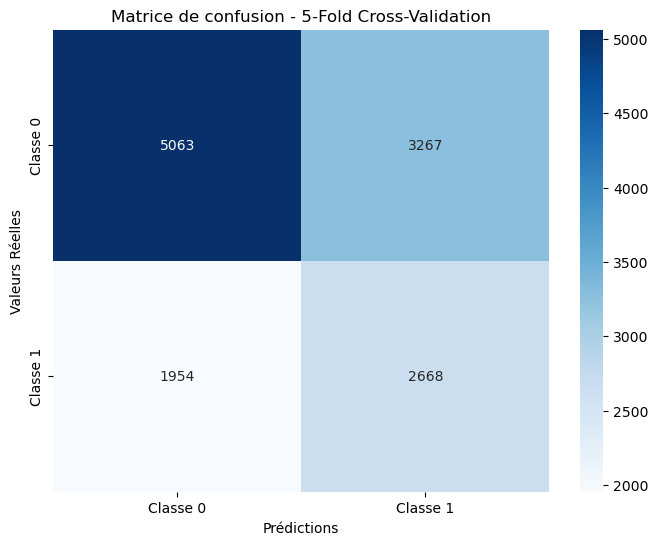

Rapport de classification :
              precision    recall  f1-score   support

           0       0.72      0.61      0.66      8330
           1       0.45      0.58      0.51      4622

    accuracy                           0.60     12952
   macro avg       0.59      0.59      0.58     12952
weighted avg       0.62      0.60      0.60     12952

Accuracy : 0.5969
Precision : 0.4495
Specificity : 0.6078


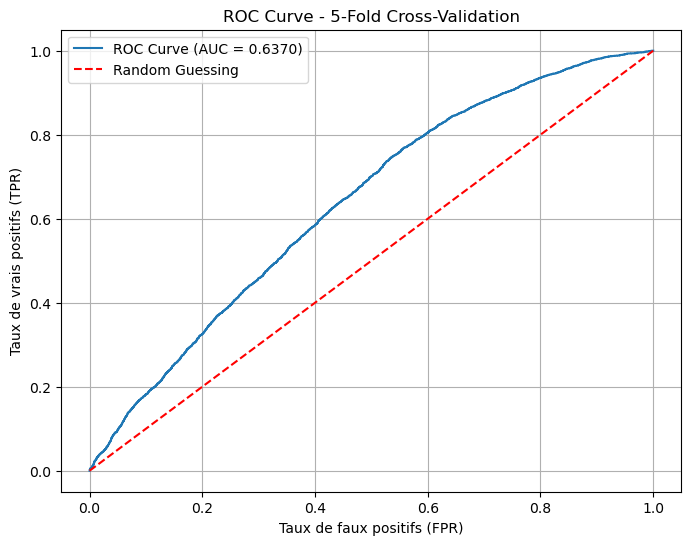

Taux de pauvreté réel : 37.4646%
Taux de pauvreté prédit : 37.3393%


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle

# Configuration des chemins
input_csv = r"D:\wealth_predict_2021\data\processed_csv\Data_EHCVM_2021_images_with_features_extracted_4096_fullyConv_sans_augm_couche_nongelee_batch_16.csv"
output_dir_csv = r"D:\wealth_predict_2021\data\processed_csv"
output_dir_models = r"D:\wealth_predict_2021\models"
output_dir_figures = r"D:\wealth_predict_2021\figures_graphs"

# Chargement des données
df = pd.read_csv(input_csv)
features = [f'feature_{i}' for i in range(4096)]
target_binary = 'pcexp_binaire'

X = df[features]
y = df[target_binary]

# Paramètre dynamique pour k-fold
k = 5  # Nombre de folds pour la cross-validation

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Réduction de dimension avec PCA
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_scaled)
num_pca_components = X_pca.shape[1]
print(f"Nombre de composantes principales expliquant 99% de la variabilité : {num_pca_components}")

# Initialisation de la régression logistique
logistic_model = LogisticRegression(class_weight='balanced', max_iter=20000, solver='saga', random_state=42)

# k-Fold Cross-Validation
kf = KFold(n_splits=k, shuffle=True, random_state=42)
y_pred = cross_val_predict(logistic_model, X_pca, y, cv=kf, method="predict")
y_proba = cross_val_predict(logistic_model, X_pca, y, cv=kf, method="predict_proba")[:, 1]

# Entraînement final du modèle
logistic_model.fit(X_pca, y)

# Sauvegarde du modèle
logistic_model_path = os.path.join(output_dir_models, f"fullyConv_sans_augm_couche_nongelee_batch_16_logistic_pca_{k}-fold_logistic_reg.pkl")
with open(logistic_model_path, 'wb') as file:
    pickle.dump(logistic_model, file)

# Évaluation des performances
conf_matrix = confusion_matrix(y, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

# Affichage de la matrice de confusion avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title(f"Matrice de confusion - {k}-Fold Cross-Validation")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
conf_matrix_path = os.path.join(output_dir_figures, f"fullyConv_sans_augm_couche_nongelee_batch_16_conf_matrix_{k}-fold_logistic_reg.png")
plt.savefig(conf_matrix_path)
plt.show()

# Rapport de classification
print("Rapport de classification :")
print(classification_report(y, y_pred))

# Calcul des métriques
accuracy = (conf_matrix[0, 0] + conf_matrix[1, 1]) / conf_matrix.sum()
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Specificity : {specificity:.4f}")

# Courbe ROC et AUC
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title(f"ROC Curve - {k}-Fold Cross-Validation")
plt.legend()
plt.grid(True)
roc_curve_path = os.path.join(output_dir_figures, f"fullyConv_sans_augm_couche_nongelee_batch_16_roc_curve_{k}-fold_logistic_reg.png")
plt.savefig(roc_curve_path)
plt.show()

# Calcul du taux de pauvreté
df['pcexp_binaire_pred'] = y_pred

# Calcul du taux de pauvreté réel
weighted_real_poverty = (
    (df['hhweight'] * df['hhsize'] * df[target_binary]).sum() /
    (df['hhweight'] * df['hhsize']).sum()
)

# Calcul du taux de pauvreté prédit
weighted_predicted_poverty = (
    (df['hhweight'] * df['hhsize'] * df['pcexp_binaire_pred']).sum() /
    (df['hhweight'] * df['hhsize']).sum()
)

print(f"Taux de pauvreté réel : {weighted_real_poverty:.4%}")
print(f"Taux de pauvreté prédit : {weighted_predicted_poverty:.4%}")

# Sauvegarde des résultats finaux
final_csv_path = os.path.join(output_dir_csv, f"fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_{k}-fold_logistic_reg.csv")
df.to_csv(final_csv_path, index=False)
